# Module 5 — Retention & Cohorts *(recap)*

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

Retention and cohort analysis are covered in two earlier repos. This module is a short recap: the ideas, what those repos showed (with their printed numbers and links), and one compact cohort table on this playbook's store data.

## From the curriculum

> ## <u>Module 5 — Retention & Cohorts</u> *(recap)*
>
> **Covered in:**
> - A/B Testing Playbook,
>   [`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb),
>   "Part 2 — Retention curves & cohort analysis" (simulated)
> - Product Analytics Case Study,
>   [`03_Engagement_and_Retention.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/03_Engagement_and_Retention.ipynb),
>   "Retention over time" and "When do withdrawals actually happen?"
>
> **Recap:** curve shapes (declining, flattening, smile), cohort comparison,
> censoring (young cohorts haven't had time).
>
> **Compact recompute:** a monthly cohort triangle on the running dataset.

## Recap

**Definitions:**
- **Retention** = the share of a group of users who are still active some time after they started.
- A **cohort** is a group of users who started in the same period, e.g. "users first seen in November". **Cohort analysis** follows each cohort separately over time, so older and newer users are not mixed.
- A **retention curve** plots retention against time since start. Three common shapes: **declining** (keeps falling toward zero), **flattening** (falls, then levels off: a core of users stays), and **smile** (falls, then rises again as some users come back).
- **Censoring:** a young cohort hasn't had time to reach later periods yet, so its later cells are empty, not zero.

### What the earlier repos showed

All numbers in this section are quoted from those notebooks' printed outputs (the A/B notebook prints fractions; they are shown as percentages here).

**1. A/B Testing Playbook,** [`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb), section "Part 2 — Retention curves & cohort analysis". Simulated data: 8 weekly cohorts of 2,000 users each. Day-30 retention fell with every newer cohort, from 29.1% (Week 1 cohort) to 8.8% (Week 8 cohort), a trend that a single pooled curve would blur.

**2. Product Analytics Case Study,** [`03_Engagement_and_Retention.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/03_Engagement_and_Retention.ipynb), sections "Retention over time" and "When do withdrawals actually happen?". Real data from an online-learning platform. It shows a retention curve compared between two groups, and when the losses happen:
- Still enrolled at week 33 (the last week every course run covers): 69.3% overall, 80.0% of activated students (active on 3 or more days in their first 14 days), 52.3% of the rest.
- Most of the loss comes early: 44.3% of all withdrawals happened by week 2 (including before the course started), and the median withdrawal week was 4.

## Compact recompute: a monthly cohort table on this store's data

The table below is the "triangle" from the curriculum: later cohorts have fewer cells, because the data ends.

**Definitions:**
- **Cohort** = users whose first event in the data falls in the same calendar month: November 2019, December 2019, January 2020 or February 2020. October is excluded: the data starts then, so "new" can't be measured (Module 2).
- **Month 0** = the cohort's own month. **Month k** = k calendar months later.
- **Retention in month k** = the share of the cohort with any event in month k.

**Data limits, up front:**
- **Calendar months:** a user first seen on 30 November reaches month 1 the next day; a user first seen on 1 November waits 30 days. So month 1 retention mixes short and long gaps. A day-based check below measures everyone over the same days.
- As in Module 2, some "new" users (most of all in November) may be older customers who were simply inactive in October.
- **Censoring:** later cohorts have fewer months of data, so their later cells are empty.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from common import connect, query, show

con = connect()
active = query(con, "SELECT DISTINCT user_id, event_month FROM daily_active")
cohort = active.groupby("user_id")["event_month"].min().rename("cohort")
active = active.join(cohort, on="user_id")
months = ["2019-10", "2019-11", "2019-12", "2020-01", "2020-02"]
position = {m: i for i, m in enumerate(months)}
active["k"] = active["event_month"].map(position) - active["cohort"].map(position)
active = active[active["cohort"] != "2019-10"]

size = active[active["k"] == 0].groupby("cohort").size()
table = active.groupby(["cohort", "k"]).size().unstack().div(size, axis=0) * 100
out = table.drop(columns=0).apply(lambda col: col.map(lambda v: "" if pd.isna(v) else f"{v:.2f}"))
out.columns = [f"month {k} %" for k in out.columns]
show(pd.concat([pd.DataFrame({"cohort": size.index, "users": size.map("{:,}".format).values}), out.reset_index(drop=True)], axis=1))
print("\n(month 0 = 100% by definition; empty cells = the data ends before that month)")
nov = table.loc["2019-11"]
print(f"November cohort, change between months: month 1 -> 2: {nov[2] - nov[1]:+.2f} points, month 2 -> 3: {nov[3] - nov[2]:+.2f} points")

cohort    users  month 1 %  month 2 %  month 3 %
2019-11  31,421      10.98       6.89       5.45
2019-12  30,136       9.23       5.33
2020-01  33,029      10.26
2020-02  29,586

(month 0 = 100% by definition; empty cells = the data ends before that month)
November cohort, change between months: month 1 -> 2: -4.09 points, month 2 -> 3: -1.44 points


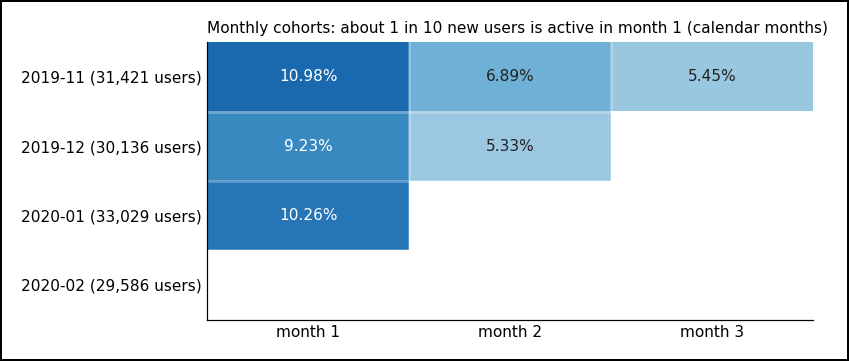

In [2]:
cells = table.drop(columns=0)
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.imshow(cells.values, cmap="Blues", vmin=0, vmax=14, aspect="auto")
for i in range(cells.shape[0]):
    for j in range(cells.shape[1]):
        v = cells.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.2f}%", ha="center", va="center", fontsize=10, color="white" if v > 8 else "#222222")
ax.set_xticks(range(cells.shape[1]), [f"month {k}" for k in cells.columns])
ax.set_yticks(range(cells.shape[0]), [f"{c} ({n:,} users)" for c, n in size.items()])
ax.set_xticks([x - 0.5 for x in range(1, cells.shape[1])], minor=True)
ax.set_yticks([y - 0.5 for y in range(1, cells.shape[0])], minor=True)
ax.grid(which="minor", color="white", linewidth=2); ax.grid(which="major", visible=False)
ax.tick_params(which="both", length=0)
ax.set_title("Monthly cohorts: about 1 in 10 new users is active in month 1 (calendar months)", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** month 1 retention is 9.23% to 10.98% across the three cohorts that have a month 1. The November cohort, the only one with three later months, goes 10.98% → 6.89% → 5.45%.

**Observation:** curve shape - the November drops shrink (−4.09 points from month 1 to 2, then −1.44 from month 2 to 3), which may be the start of flattening; three later months are too few to tell.

**Observation:** month 1 retention varies little between cohorts (10.98%, 9.23%, 10.26%). Three cohorts are too few to tell whether the differences mean anything.

**Day-based check.** To give everyone the same gap, retention is also measured per user from their own first day: active on days 30–59, 60–89 and 90–119 after their first event. A cohort is shown for a window only if every member has the whole window inside the data.

In [3]:
days = query(con, "SELECT user_id, event_date FROM daily_active")
days["event_date"] = pd.to_datetime(days["event_date"])
first = days.groupby("user_id")["event_date"].min().rename("day0")
days = days.join(first, on="user_id")
days["d"] = (days["event_date"] - days["day0"]).dt.days
days["cohort"] = days["day0"].dt.strftime("%Y-%m")
last_day = days["event_date"].max()
rows = []
for c in ["2019-11", "2019-12", "2020-01"]:
    members = first[first.dt.strftime("%Y-%m") == c]
    row = {"cohort": c, "users": f"{len(members):,}"}
    for lo in (30, 60, 90):
        if (members + pd.Timedelta(days=lo + 29)).max() <= last_day:
            hit = days[(days["cohort"] == c) & days["d"].between(lo, lo + 29)]["user_id"].nunique()
            row[f"days {lo}-{lo + 29} %"] = f"{hit / len(members) * 100:.2f}"
        else:
            row[f"days {lo}-{lo + 29} %"] = ""
    rows.append(row)
show(pd.DataFrame(rows))
print("\n(empty = not every member has the whole window inside the data)")

cohort    users  days 30-59 %  days 60-89 %  days 90-119 %
2019-11  31,421          7.26          6.42
2019-12  30,136          6.94
2020-01  33,029

(empty = not every member has the whole window inside the data)


**Observation:** day-based check - active on days 30–59 after their first event: 7.26% (November cohort) and 6.94% (December). That is about 1 in 14, lower than the calendar-month 1 in 10, because the calendar month 1 includes users who reach it after only a day or two. The November cohort then stays near the same level (6.42% on days 60–89), so the day-based curve is already fairly flat.

**Conclusion:** the calendar-month table overstates the drop in its first step. Measured over equal windows, retention is lower and flatter.

### Weekly cohorts, day-based

Monthly cohorts give at most three later months. Weekly cohorts give a longer view, still with equal windows for everyone.

**Definitions:**
- **Cohort** = users first seen in the same week (Monday to Sunday), from the week starting 4 November 2019. Users first seen on 1–3 November are left out: their week starts in October.
- **Day-based** = time is counted from each user's own first day, not by the calendar, so every user gets equal windows.
- **Week k** = days 7k to 7k+6 after the user's own first day (week 1 = days 7–13).
- **Retention in week k** = the share of the cohort with any event in week k.
- A cell is shown only if every member of the cohort has that whole week inside the data. The last two cohorts have no complete week 1 yet, so they are left out.

In [4]:
week_start = first - pd.to_timedelta(first.dt.weekday, unit="D")
week_start = week_start[week_start >= "2019-11-04"]
days["w"] = days["d"] // 7
weekly = {}
for start, members in week_start.groupby(week_start):
    ids = members.index
    latest = first[ids].max()
    member_days = days[days["user_id"].isin(ids)]
    row = {}
    for k in range(1, 16):
        if latest + pd.Timedelta(days=7 * k + 6) <= last_day:
            row[k] = member_days[member_days["w"] == k]["user_id"].nunique() / len(ids) * 100
    if row:
        weekly[(start.strftime("%Y-%m-%d"), len(ids))] = row
weekly = pd.DataFrame(weekly).T
print(f"{len(weekly)} weekly cohorts, {weekly.index.get_level_values(1).min():,} to {weekly.index.get_level_values(1).max():,} users each")
print(f"week 1: {weekly[1].min():.2f}% to {weekly[1].max():.2f}% across the {weekly[1].notna().sum()} cohorts that reach it")
for k in (6, 8, 12):
    print(f"week {k}: {weekly[k].min():.2f}% to {weekly[k].max():.2f}% across the {weekly[k].notna().sum()} cohorts that reach it")
low = weekly[1].nsmallest(2)
print("lowest week 1: " + ", ".join(f"cohort of {i[0]} ({v:.2f}%)" for i, v in low.items()))

15 weekly cohorts, 5,969 to 8,090 users each
week 1: 4.60% to 8.14% across the 15 cohorts that reach it
week 6: 1.91% to 2.57% across the 10 cohorts that reach it
week 8: 1.67% to 2.59% across the 8 cohorts that reach it
week 12: 1.49% to 2.38% across the 4 cohorts that reach it
lowest week 1: cohort of 2019-12-23 (4.60%), cohort of 2019-12-16 (4.72%)


average, weighted by cohort size (cohorts included):
  wk 1: 6.13% (15), wk 2: 4.61% (14), wk 3: 3.44% (13), wk 4: 2.90% (12), wk 5: 2.49% (11), wk 6: 2.28% (10), wk 7: 2.12% (9), wk 8: 2.09% (8), wk 9: 2.13% (7), wk 10: 2.02% (6), wk 11: 1.98% (5), wk 12: 1.93% (4), wk 13: 1.82% (3), wk 14: 1.80% (2), wk 15: 1.67% (1)
  change from the week before: wk 2: -1.52, wk 3: -1.17, wk 4: -0.54, wk 5: -0.40, wk 6: -0.21, wk 7: -0.16, wk 8: -0.03, wk 9: +0.04, wk 10: -0.11, wk 11: -0.04, wk 12: -0.05, wk 13: -0.12, wk 14: -0.01, wk 15: -0.13


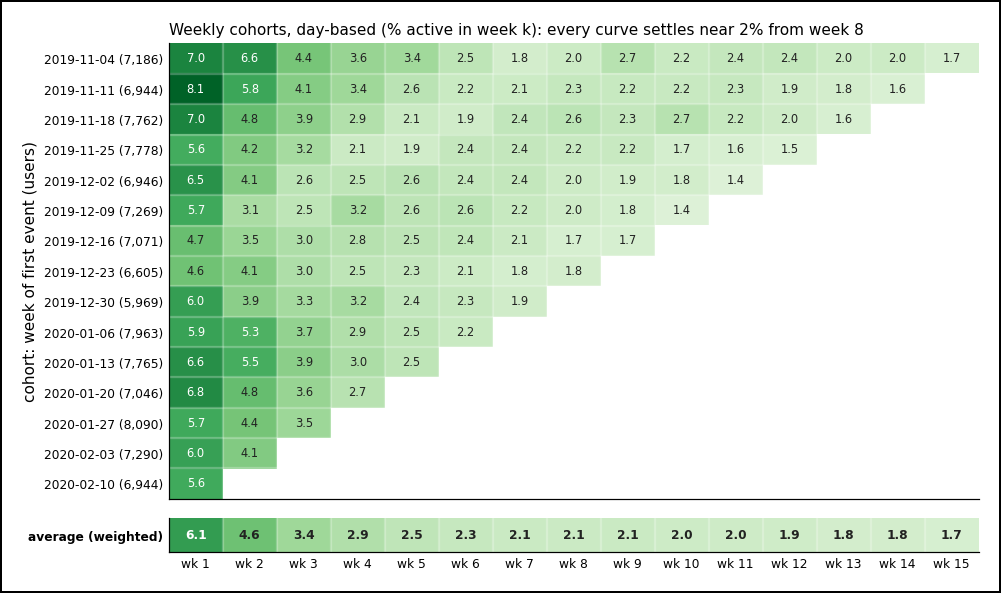

In [5]:
sizes = pd.Series(weekly.index.get_level_values(1), index=weekly.index)
avg = weekly.apply(lambda col: (col * sizes)[col.notna()].sum() / sizes[col.notna()].sum())
n_cohorts = weekly.notna().sum()
print("average, weighted by cohort size (cohorts included):")
print("  " + ", ".join(f"wk {k}: {v:.2f}% ({n_cohorts[k]})" for k, v in avg.items()))
print("  change from the week before: " + ", ".join(f"wk {k}: {avg[k] - avg[k - 1]:+.2f}" for k in avg.index[1:]))

fig, (ax, ax_avg) = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True,
                                 gridspec_kw={"height_ratios": [weekly.shape[0], 1.1], "hspace": 0.08})
ax.imshow(weekly.values, cmap="Greens", vmin=0, vmax=9, aspect="auto")
ax_avg.imshow(avg.values[None, :], cmap="Greens", vmin=0, vmax=9, aspect="auto")
for i in range(weekly.shape[0]):
    for j in range(weekly.shape[1]):
        v = weekly.iat[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7.5, color="white" if v > 5 else "#222222")
for j, v in enumerate(avg.values):
    ax_avg.text(j, 0, f"{v:.1f}", ha="center", va="center", fontsize=8, fontweight="bold", color="white" if v > 5 else "#222222")
ax.set_yticks(range(weekly.shape[0]), [f"{s} ({n:,})" for s, n in weekly.index], fontsize=8)
ax_avg.set_yticks([0], ["average (weighted)"], fontsize=8, fontweight="bold")
ax_avg.set_xticks(range(weekly.shape[1]), [f"wk {k}" for k in weekly.columns], fontsize=8)
for a, rows in ((ax, weekly.shape[0]), (ax_avg, 1)):
    a.set_xticks([x - 0.5 for x in range(1, weekly.shape[1])], minor=True)
    a.set_yticks([y - 0.5 for y in range(1, rows)], minor=True)
    a.grid(which="minor", color="white", linewidth=1.5); a.grid(which="major", visible=False)
    a.tick_params(which="both", length=0)
ax.set_ylabel("cohort: week of first event (users)")
ax.set_title("Weekly cohorts, day-based (% active in week k): every curve settles near 2% from week 8", fontsize=10, loc="left")
plt.show()

**Observation:** week 1 retention ranges from 4.60% to 8.14% across 15 cohorts. Every cohort's curve falls over the first weeks and then levels off: by week 8 the range is 1.67% to 2.59%, and by week 12 it is 1.49% to 2.38%.

**Observation:** the two lowest week 1 values belong to the cohorts starting 23 and 16 December (4.60% and 4.72%).

**Observation:** average row (weighted by cohort size): 6.13% in week 1, then the biggest drops are into week 2 (−1.52 points) and week 3 (−1.17). The drops shrink through week 7 (−0.16), and from week 8 the average barely moves (between −0.13 and +0.04 per week). Later weeks average fewer, earlier cohorts (week 12: 4 cohorts, week 15: 1), so the right end of the row rests on fewer users.

**Hypothesis:** the December dip reflects the holidays: those users' first week after joining fell in the quietest days of the data (Module 4 shows 30–31 December as the lowest days). The log has no way to confirm it.

**Conclusion:** with 15 cohorts, the shape is clear and consistent: a steep drop over the first 3 weeks, a slowing drop to week 7, then a flat level around 2% from week 8: a flattening curve, with a small core of returning users.

## Key takeaways

- **Recap:** retention is read cohort by cohort, because a single pooled curve blurs trends between cohorts (A/B Testing Playbook, `02_b2c_product_metrics.ipynb`).
- **Recap:** censored cells are empty, not zero.
- **Observation:** on this store, month 1 retention is about 1 in 10 by calendar month (9.23% to 10.98%), but about 1 in 14 on equal windows (7.26% and 6.94% on days 30–59).
- **Observation:** the November cohort falls from 10.98% (month 1) to 5.45% (month 3) by calendar month; on equal windows its curve is already fairly flat (7.26% → 6.42%).
- **Observation:** weekly cohorts (15 of them, day-based) show the same shape every time: a steep drop over the first 3 weeks, then a flat level around 2% from week 8.
- **Conclusion:** how retention windows are defined changes the answer; equal windows per user are the fairer comparison.